In [18]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11
})
from biot_gassmann import gassmann,biot_gassmann_wood,biot_gassmann_hill
from wiff_sphere import white_sphere_1975,biot_sphere_matrix,dynamic_biot_sphere_matrix

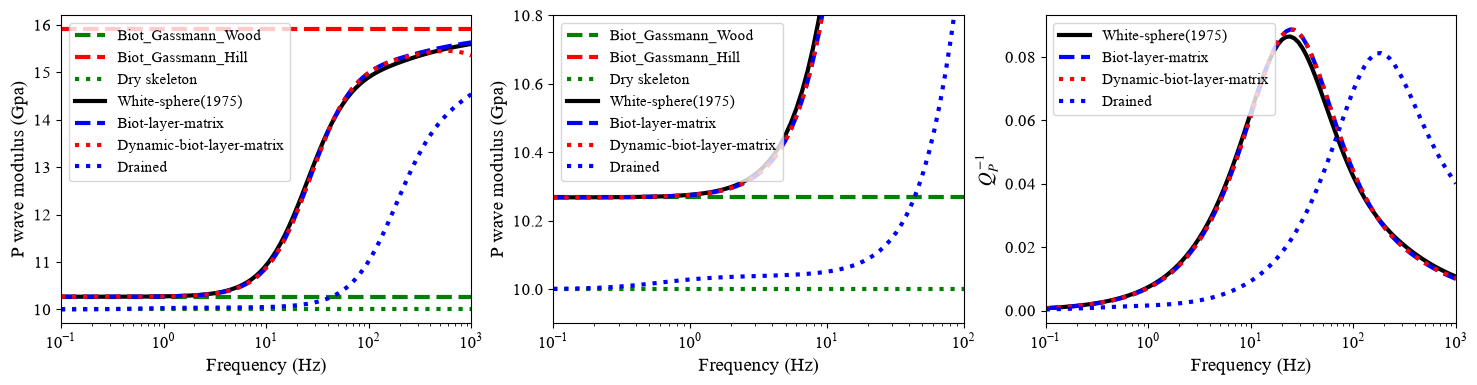

In [19]:
Ks   = 38e9 # Pa
Gs   = 44e9
rhos = 2.65e3 # Kg/m^3
Kd   = 10e9
Gd   = 12e9
phi  = 0.15
perm0= 100e-15 # 100 mD
f    = np.logspace(-1,3,100)
# inner sphere
Kf_in   = 9.6e6
rhof_in = 50
vis_in  = 1e-5 # Pa·s
# Outer shell
Kf_out   = 2.4e9
rhof_out = 1e3
vis_out  = 1e-3 # Pa·s

skeleton  = [Ks,Gs,rhos,Kd,Gd,phi]
fluid_in  = [Kf_in,rhof_in,vis_in]
fluid_out = [Kf_out,rhof_out,vis_out]
a = 0.1
b = 0.2
K_white = white_sphere_1975(skeleton,fluid_in,fluid_out,perm0,a,b,f)[0]

rock_in   = skeleton
rock_out  = skeleton 
perm      = [perm0,perm0]
K_static  = biot_sphere_matrix(rock_in,rock_out,fluid_in,fluid_out,perm,a,b,f,Pc=1e3,undrained=1,Pf_out=0)[0]
K_dynamic = dynamic_biot_sphere_matrix(rock_in,rock_out,fluid_in,fluid_out,perm,a,b,f,s=[1,1],Pc=15e3,undrained=1,Pf_out=0)
K_drained = biot_sphere_matrix(rock_in,rock_out,fluid_in,fluid_out,perm,a,b,f,Pc=1e3,undrained=0,Pf_out=0)[0]

fraction = [(a/b)**3,1-(a/b)**3]
Kf = [Kf_in,Kf_out]
K_lower = biot_gassmann_wood(Kd,Gd,Ks,Kf,phi,fraction) - 4/3*Gd
K_high  = biot_gassmann_hill(Kd,Gd,Ks,Kf,phi,fraction) - 4/3*Gd

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.semilogx([f.min(),f.max()],[K_lower/1e9,K_lower/1e9],
             label='Biot_Gassmann_Wood',color='green',linestyle='--',linewidth=3)
plt.semilogx([f.min(),f.max()],[K_high/1e9,K_high/1e9],
             label='Biot_Gassmann_Hill',color='red',linestyle='--',linewidth=3)
plt.semilogx([f.min(),f.max()],[Kd/1e9,Kd/1e9],
             label='Dry skeleton',color='green',linestyle=':',linewidth=3)
plt.semilogx(f,np.real(K_white)/1e9,
             label='White-sphere(1975)',color='black',linewidth=3)
plt.semilogx(f,np.real(K_static)/1e9,
             label='Biot-layer-matrix',color='blue',linestyle='--',linewidth=3)
plt.semilogx(f,np.real(K_dynamic)/1e9,
             label='Dynamic-biot-layer-matrix',color='red',linestyle=':',linewidth=3)
plt.semilogx(f,np.real(K_drained)/1e9,
             label='Drained',color='blue',linestyle=':',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('P wave modulus (Gpa)')
plt.legend(loc='upper left')
plt.xlim(f.min(),f.max())

plt.subplot(1,3,2)
plt.semilogx([f.min(),f.max()],[K_lower/1e9,K_lower/1e9],
             label='Biot_Gassmann_Wood',color='green',linestyle='--',linewidth=3)
plt.semilogx([f.min(),f.max()],[K_high/1e9,K_high/1e9],
             label='Biot_Gassmann_Hill',color='red',linestyle='--',linewidth=3)
plt.semilogx([f.min(),f.max()],[Kd/1e9,Kd/1e9],
             label='Dry skeleton',color='green',linestyle=':',linewidth=3)
plt.semilogx(f,np.real(K_white)/1e9,
             label='White-sphere(1975)',color='black',linewidth=3)
plt.semilogx(f,np.real(K_static)/1e9,
             label='Biot-layer-matrix',color='blue',linestyle='--',linewidth=3)
plt.semilogx(f,np.real(K_dynamic)/1e9,
             label='Dynamic-biot-layer-matrix',color='red',linestyle=':',linewidth=3)
plt.semilogx(f,np.real(K_drained)/1e9,
             label='Drained',color='blue',linestyle=':',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('P wave modulus (Gpa)')
plt.legend(loc='upper left')
plt.xlim(1e-1,1e2)
plt.xticks([1e-1,1e0,1e1,1e2])
plt.ylim(9.9,10.8)

plt.subplot(1,3,3)
plt.semilogx(f,np.imag(K_white+4/3*Gd)/np.real(K_white+4/3*Gd),
             label='White-sphere(1975)',color='black',linewidth=3)
plt.semilogx(f,np.imag(K_static+4/3*Gd)/np.real(K_static+4/3*Gd),
             label='Biot-layer-matrix',color='blue',linestyle='--',linewidth=3)
plt.semilogx(f,np.imag(K_dynamic+4/3*Gd)/np.real(K_dynamic+4/3*Gd),
             label='Dynamic-biot-layer-matrix',color='red',linestyle=':',linewidth=3)
plt.semilogx(f,np.imag(K_drained+4/3*Gd)/np.real(K_drained+4/3*Gd),
             label='Drained',color='blue',linestyle=':',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'$Q_{P}^{-1}$')
plt.legend(loc='upper left')
plt.xlim(f.min(),f.max())

plt.show()

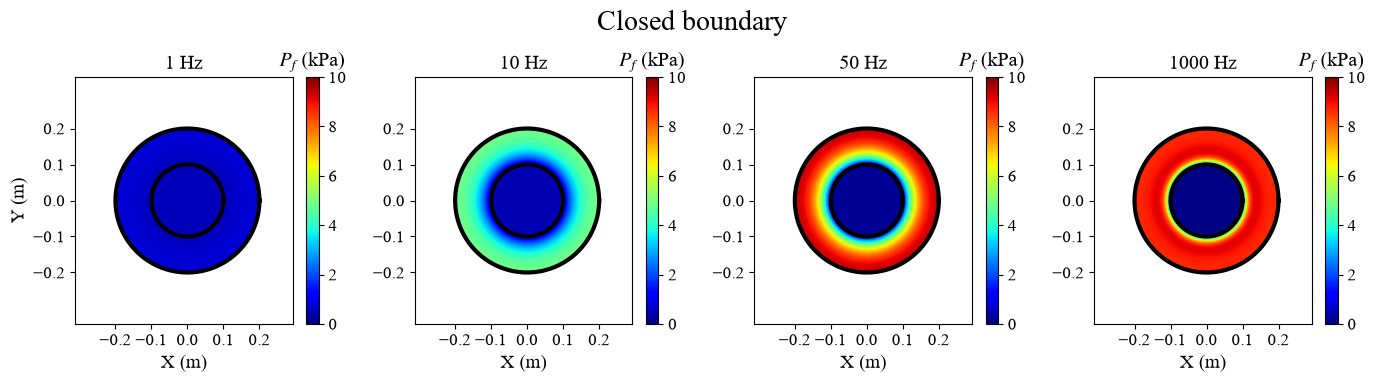

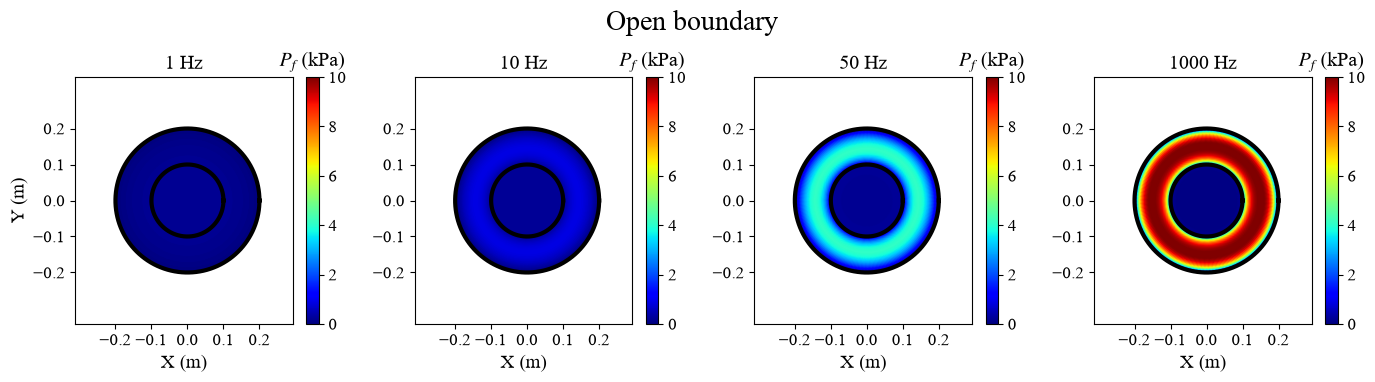

In [20]:
f  = [1,10,50,1000]
x = np.arange(10)
r = biot_sphere_matrix(rock_in,rock_out,fluid_in,fluid_out,perm,a,b,f[0],Pc=15e3,undrained=1,Pf_out=0)[1]
pf_close = np.zeros((len(f),len(r)),dtype=np.complex128)
pf_open  = np.zeros((len(f),len(r)),dtype=np.complex128)
# close boundary
for i in range(len(f)):
    pf_close[i,:] = biot_sphere_matrix(rock_in,rock_out,fluid_in,fluid_out,perm,a,b,f[i],Pc=15e3,undrained=1,Pf_out=0)[2]
# open baundary
for i in range(len(f)):
    pf_open[i,:]  = biot_sphere_matrix(rock_in,rock_out,fluid_in,fluid_out,perm,a,b,f[i],Pc=15e3,undrained=0,Pf_out=0)[2]

theta = np.linspace(0, 2*np.pi, 300)
R, Theta = np.meshgrid(r, theta)
X = R * np.cos(Theta)
Y = R * np.sin(Theta)
theta_circle = np.linspace(0, 2*np.pi, 500)

plt.figure(figsize=(14,4))
for i in range(len(f)):
    plt.subplot(1,4,i+1)
    pf_abs = np.abs(pf_close[i,:])/1e3
    pf_2d = np.tile(pf_abs,(len(theta),1))
    im = plt.pcolormesh(X,Y,pf_2d,
        shading='gouraud',cmap='jet',vmin=0,vmax=10)
    plt.plot(a * np.cos(theta_circle),a * np.sin(theta_circle),'k-',linewidth=3)
    plt.plot(b * np.cos(theta_circle),b * np.sin(theta_circle),'k-',linewidth=3)
    plt.axis('equal')
    plt.xticks([-b,-a,0,a,b])
    plt.yticks([-b,-a,0,a,b])
    plt.title(f'{f[i]} Hz')
    plt.xlabel('X (m)')
    if i == 0:
        plt.ylabel('Y (m)')
    cbar = plt.colorbar(im)
    cbar.ax.set_title(r'$P_f$ (kPa)',pad=8)    
plt.suptitle('Closed boundary',fontsize=20,y=0.95)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,4))
for i in range(len(f)):
    plt.subplot(1,4,i+1)
    pf_abs = np.abs(pf_open[i,:])/1e3
    pf_2d = np.tile(pf_abs,(len(theta),1))
    im = plt.pcolormesh(X,Y,pf_2d,
        shading='gouraud',cmap='jet',vmin=0,vmax=10)
    plt.plot(a * np.cos(theta_circle),a * np.sin(theta_circle),'k-',linewidth=3)
    plt.plot(b * np.cos(theta_circle),b * np.sin(theta_circle),'k-',linewidth=3)
    plt.axis('equal')
    plt.xticks([-b,-a,0,a,b])
    plt.yticks([-b,-a,0,a,b])
    plt.title(f'{f[i]} Hz')
    plt.xlabel('X (m)')
    if i == 0:
        plt.ylabel('Y (m)')
    cbar = plt.colorbar(im)
    cbar.ax.set_title(r'$P_f$ (kPa)',pad=8)    
plt.suptitle('Open boundary',fontsize=20,y=0.95)
plt.tight_layout()
plt.show()